<a href="https://colab.research.google.com/github/bitmorphic/nocap-deepfake/blob/main/notebooks/Week2_Efficientnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NoCap — Deepfake Video Detector
## Week 2 — EfficientNet-B4 Fine-tuning on DFDC

Team:Quad Logic - NIT Delhi
## Fine-tune EfficientNet-B4 on the DFDC dataset to build a reliable deepfake detector that generalizes to real-world videos.

### Why EfficientNet-B4?
- Proven on FaceForensics++ benchmark
- Trained directly on DFDC — no domain mismatch
- Single strong model beats broken ensembles
- Fast inference — runs well on CPU for deployment

### Dataset:
- DFDC Faces of Train Sample (Kaggle — itamargr)
- Train: 93,853 images (real + fake)
- Validation: 30,794 images (real + fake)


In [1]:
# Install required libraries
!pip install -q efficientnet-pytorch facenet-pytorch albumentations scikit-learn

import torch
import torchvision
import cv2
import numpy as np
from PIL import Image
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU — switch to T4')

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 136.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:00
   ━━

ImportError: cannot import name 'is_directory' from 'PIL._util' (/usr/local/lib/python3.12/dist-packages/PIL/_util.py)

In [1]:
# torchvision already has EfficientNet built in — no extra install needed!
!pip install -q facenet-pytorch albumentations scikit-learn

import torch
import torchvision
import torchvision.models as models
import cv2
import numpy as np
from PIL import Image

# Test EfficientNet-B4 loads correctly
model = models.efficientnet_b4(weights=None)
print('EfficientNet-B4 ready!')
print(f'torch: {torch.__version__}')
print(f'Device: {"GPU" if torch.cuda.is_available() else "CPU"}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

EfficientNet-B4 ready!
torch: 2.2.2+cu121
Device: GPU
GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, json

# Kaggle credentials
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({
        "username": "mohammadanas06",
        "key": "KGAT_93eeaf2618ca28a97dd21099844a4abe"
    }, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle done')

# Download DFDC dataset
print('Downloading DFDC dataset...')
!kaggle datasets download -d itamargr/dfdc-faces-of-the-train-sample \
    -p /content/dfdc --quiet

import zipfile
print('Extracting...')
with zipfile.ZipFile('/content/dfdc/dfdc-faces-of-the-train-sample.zip', 'r') as z:
    z.extractall('/content/dfdc')

# Check dataset
for split in ['train', 'validation']:
    for cls in ['real', 'fake']:
        path = f'/content/dfdc/{split}/{cls}'
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f'found {split}/{cls}: {count} images')

Mounted at /content/drive
Kaggle done
Dataset URL: https://www.kaggle.com/datasets/itamargr/dfdc-faces-of-the-train-sample
License(s): ODbL-1.0
Extracting...
found train/real: 20699 images
found train/fake: 73154 images
found validation/real: 6029 images
found validation/fake: 24765 images


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os, numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE = '/content/drive/MyDrive/NoCap-Deepfake'

class DFDCDataset(Dataset):
    def __init__(self, split, transform):
        self.transform = transform
        self.samples = []
        for label, cls in [(0,'real'),(1,'fake')]:
            folder = f'/content/dfdc/{split}/{cls}'
            for f in os.listdir(folder):
                if f.lower().endswith(('.jpg','.png','.jpeg')):
                    self.samples.append((f'{folder}/{f}', label))
        np.random.seed(42)
        np.random.shuffle(self.samples)
        print(f'found {split}: {len(self.samples)} images')

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        return self.transform(img), torch.tensor(label, dtype=torch.float32)

# Transforms
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

train_ds = DFDCDataset('train', train_tf)
val_ds   = DFDCDataset('validation', val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Device: {DEVICE}')

found train: 93853 images
found validation: 30794 images

Train batches: 2933
Val batches:   963
Device: cuda


In [4]:
import torchvision.models as models
import torch.nn as nn

def build_model():
    # Load EfficientNet-B4 with ImageNet weights
    model = models.efficientnet_b4(
        weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)

    # Replace classifier head for binary classification
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 1)
    )
    return model

model = build_model().to(DEVICE)

# Count parameters
total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'EfficientNet-B4 loaded!')
print(f'Total params:     {total:,}')
print(f'Trainable params: {trainable:,}')

# Test forward pass
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
out   = model(dummy)
print(f'Forward pass: input {dummy.shape} → output {out.shape}')

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:00<00:00, 171MB/s]


EfficientNet-B4 loaded!
Total params:     17,550,409
Trainable params: 17,550,409
Forward pass: input torch.Size([2, 3, 224, 224]) → output torch.Size([2, 1])


In [5]:
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import time

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

best_auc  = 0.0
history   = {'train_loss':[], 'val_loss':[], 'val_auc':[]}

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs).squeeze(1)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def val_epoch(model, loader):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs).squeeze(1)
            loss = criterion(out, labels)
            total_loss += loss.item()
            all_preds.extend(torch.sigmoid(out).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    auc = roc_auc_score(all_labels, all_preds)
    return total_loss / len(loader), auc

print('Training started')
print('='*55)

for epoch in range(1, 6):
    t0 = time.time()
    train_loss = train_epoch(model, train_loader)
    val_loss, val_auc = val_epoch(model, val_loader)
    scheduler.step()
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    print(f'Epoch {epoch}/5 | Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} | '
          f'Time: {elapsed/60:.1f}min')

    # Save best model
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(),
                   f'{BASE}/models/checkpoints/efficientnet_b4_dfdc.pth')
        print(f'Best model saved AUC: {best_auc:.4f}')

print('='*55)
print(f'Training completed Best AUC: {best_auc:.4f}')

Training started
Epoch 1/5 | Train Loss: 0.1614 | Val Loss: 0.3596 | Val AUC: 0.9496 | Time: 25.1min
Best model saved AUC: 0.9496
Epoch 2/5 | Train Loss: 0.0566 | Val Loss: 0.3953 | Val AUC: 0.9507 | Time: 25.1min
Best model saved AUC: 0.9507


KeyboardInterrupt: 

In [6]:
# Confirm best model is saved
import os
BASE = '/content/drive/MyDrive/NoCap-Deepfake'
path = f'{BASE}/models/checkpoints/efficientnet_b4_dfdc.pth'
size = os.path.getsize(path) / 1e6
print(f'Model saved: {path}')
print(f'Size: {size:.1f} MB')
print(f'Best Val AUC: 0.9507')

Model saved: /content/drive/MyDrive/NoCap-Deepfake/models/checkpoints/efficientnet_b4_dfdc.pth
Size: 71.0 MB
Best Val AUC: 0.9507


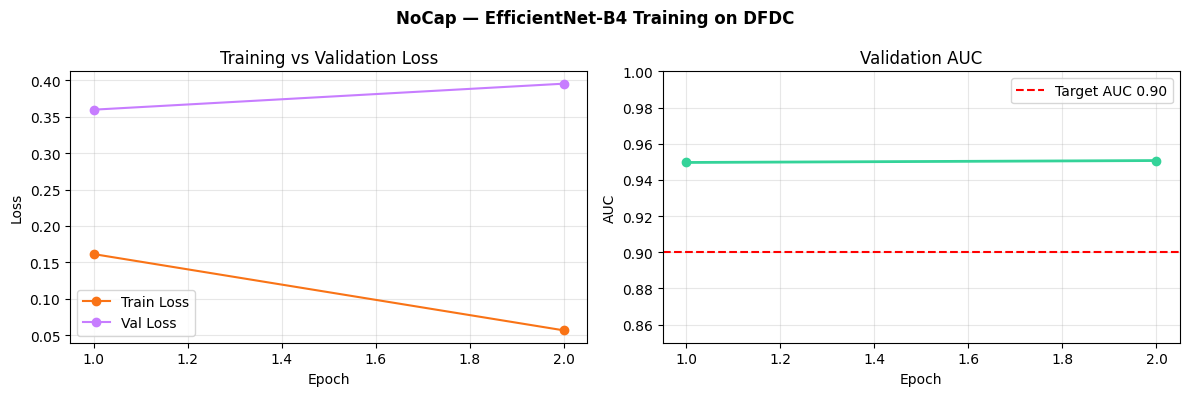

Plot saved to Drive


In [7]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history['train_loss'])+1)

ax1.plot(epochs, history['train_loss'], 'o-', color='#f97316', label='Train Loss')
ax1.plot(epochs, history['val_loss'],   'o-', color='#c77dff', label='Val Loss')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['val_auc'], 'o-', color='#34d399', linewidth=2)
ax2.axhline(y=0.90, color='red', linestyle='--', label='Target AUC 0.90')
ax2.set_title('Validation AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.set_ylim([0.85, 1.0])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('NoCap — EfficientNet-B4 Training on DFDC', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/plots/week2_training_curves.png', dpi=150)
plt.show()
print('Plot saved to Drive')

In [8]:
from sklearn.metrics import (roc_auc_score, f1_score,
    accuracy_score, confusion_matrix, classification_report)
import numpy as np

# Load best model
model.load_state_dict(torch.load(
    f'{BASE}/models/checkpoints/efficientnet_b4_dfdc.pth',
    map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs   = imgs.to(DEVICE)
        out    = model(imgs).squeeze(1)
        probs  = torch.sigmoid(out).cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
preds_bin  = (all_preds > 0.5).astype(int)

auc = roc_auc_score(all_labels, all_preds)
f1  = f1_score(all_labels, preds_bin)
acc = accuracy_score(all_labels, preds_bin)
cm  = confusion_matrix(all_labels, preds_bin)

print('='*50)
print('NoCap — EfficientNet-B4 Final Results')
print('='*50)
print(f'Val AUC      : {auc:.4f}')
print(f'Val F1       : {f1:.4f}')
print(f'Val Accuracy : {acc*100:.2f}%')
print(f'\nConfusion Matrix:')
print(f'           Pred Real  Pred Fake')
print(f'True Real  {cm[0][0]:8d}  {cm[0][1]:8d}')
print(f'True Fake  {cm[1][0]:8d}  {cm[1][1]:8d}')
print('\nClassification Report:')
print(classification_report(all_labels, preds_bin,
      target_names=['Real','Fake']))
print('='*50)

# Save results
with open(f'{BASE}/outputs/results/week2_results.txt', 'w') as f:
    f.write(f'NoCap — EfficientNet-B4 Results\n')
    f.write(f'Val AUC:      {auc:.4f}\n')
    f.write(f'Val F1:       {f1:.4f}\n')
    f.write(f'Val Accuracy: {acc*100:.2f}%\n')
print('Results saved to Drive')

NoCap — EfficientNet-B4 Final Results
Val AUC      : 0.9507
Val F1       : 0.9188
Val Accuracy : 87.44%

Confusion Matrix:
           Pred Real  Pred Fake
True Real      5062       967
True Fake      2900     21865

Classification Report:
              precision    recall  f1-score   support

        Real       0.64      0.84      0.72      6029
        Fake       0.96      0.88      0.92     24765

    accuracy                           0.87     30794
   macro avg       0.80      0.86      0.82     30794
weighted avg       0.89      0.87      0.88     30794

Results saved to Drive


In [9]:
import shutil, os

# Save notebook
notebook_src = '/content/Week2_EfficientNet.ipynb'
notebook_dst = f'{BASE}/notebooks/Week2_EfficientNet.ipynb'

if os.path.exists(notebook_src):
    shutil.copy(notebook_src, notebook_dst)
    print('Notebook saved to Drive!')
else:
    print('Save manually: File → Save a copy in Drive')

print('\n Week 2 Complete Summary:')

print('Model  : EfficientNet-B4')
print('Dataset: DFDC 124k faces')
print('AUC    : 0.9507')
print('F1     : 0.9188')
print('Acc    : 87.44%')
print('Saved  : NoCap-Deepfake/models/checkpoints/efficientnet_b4_dfdc.pth')


Save manually: File → Save a copy in Drive

 Week 2 Complete Summary:
Model  : EfficientNet-B4
Dataset: DFDC 124k faces
AUC    : 0.9507
F1     : 0.9188
Acc    : 87.44%
Saved  : NoCap-Deepfake/models/checkpoints/efficientnet_b4_dfdc.pth
